# 02 — Fator de demanda (tarifa dinâmica por kWh)

No EV ChargeOps o custo de cada recarga é rateado por kWh. O **fator de demanda** é um multiplicador aplicado à tarifa base no momento em que o morador inicia a recarga:

```
preço por kWh = tarifa base × fator de demanda      (fator entre 0,8 e 1,5)
```

A ideia é simples: quando o estacionamento está vazio, a recarga fica mais barata (fator 0,8) e incentiva o uso em horários de folga; quando está cheio ou com fila, fica mais cara (até 1,5) e desestimula ocupar o ponto sem necessidade. Isso distribui melhor o uso dos carregadores compartilhados e reduz picos de consumo, que é o interesse da GoodWe na gestão de energia do condomínio.

O fator é calculado em duas etapas:

1. Um **GradientBoostingRegressor** prevê o **índice de demanda das próximas 3 horas** a partir do estado atual: hora, dia da semana, ocupação, fila e tipo de ponto (as mesmas informações que o backend envia para `POST /demand-factor`).
2. Uma **regra de negócio transparente** converte o índice previsto em fator de preço.

Separar previsão e regra de preço é intencional: o síndico consegue entender e ajustar a regra sem retreinar o modelo, e o modelo continua avaliável com métricas de regressão comuns.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

from ml.config import (
    ARTIFACTS_DIR,
    COMMERCIAL,
    DEMAND_FACTOR_MODEL,
    DEMAND_FACTOR_VERSION,
    PRIVATE,
    RANDOM_SEED,
)
from ml.data.hourly import build_hourly_panel
from ml.data.loaders import load_sessions
from ml.features import DEMAND_FEATURES, build_demand_features
from ml.models.demand_factor import (
    DEMAND_KNOTS,
    ESTIMATOR_PARAMS,
    FACTOR_KNOTS,
    DemandFactorModel,
    demand_to_factor,
)
from ml.training.datasets import build_demand_dataset
from ml.training.evaluate import hourly_mean_baseline, regression_metrics

pd.set_option("display.precision", 3)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
COLORS = {PRIVATE: "#2a78d6", COMMERCIAL: "#eb6834"}
TYPES = [PRIVATE, COMMERCIAL]

## 1. Conjunto de treino

Partimos do painel hora a hora construído no notebook 01 (`build_hourly_panel`). Para cada local e hora *t*:

- **Entradas:** `hour`, `day_of_week`, `occupancy_ratio`, `queue_length` e `charge_point_type` medidos no início da hora *t* (a foto do estado atual).
- **Alvo (`next_demand`):** média do índice de demanda nas horas *t*, *t+1* e *t+2*, ou seja, a média de carros conectados nas próximas 3 horas dividida pela capacidade do local. Vale 0 com o estacionamento vazio, 1 com ele na capacidade e passa de 1 quando há mais carros que a capacidade estimada (limitado a 1,5). O horizonte de 3 horas corresponde ao tempo típico em que o carro está de fato carregando (notebook 01, seção 5).

A divisão entre treino e teste é **temporal**: para cada local, as últimas 20% das horas ficam para teste. Uma divisão aleatória vazaria informação, porque horas vizinhas são quase iguais.

In [2]:
sessions = load_sessions()
dataset = build_demand_dataset(build_hourly_panel(sessions))
train = dataset[~dataset["is_test"]]
test = dataset[dataset["is_test"]]
pd.DataFrame(
    {
        "train_rows": train.groupby("charge_point_type").size(),
        "test_rows": test.groupby("charge_point_type").size(),
        "mean_next_demand": dataset.groupby("charge_point_type")["next_demand"].mean(),
    }
)

,train_rows,test_rows,mean_next_demand
charge_point_type,,,
COMMERCIAL,99872,24958,0.177
PRIVATE,82997,20745,0.428


## 2. Escolha dos hiperparâmetros

Para não escolher hiperparâmetros olhando o teste, separamos as últimas 20% das horas de **treino** de cada local como validação. Comparamos quatro configurações: função de perda quadrática ou Huber (mais robusta a picos isolados) e árvores com profundidade 3 ou 5. A mesma validação também mede os dois **baselines**, que qualquer modelo precisa superar para justificar sua existência:

- **Persistência:** a demanda da próxima hora é igual à ocupação atual.
- **Média histórica:** média do alvo no treino para o mesmo tipo de ponto, hora e dia da semana.

In [3]:
position = train.groupby("site_id").cumcount()
size = train.groupby("site_id")["timestamp"].transform("size")
is_validation = position >= size * 0.8
fit_part, validation = train[~is_validation], train[is_validation]

candidates = {
    "quadrática, profundidade 3": {"loss": "squared_error", "max_depth": 3},
    "quadrática, profundidade 5": {"loss": "squared_error", "max_depth": 5},
    "Huber, profundidade 3": {"loss": "huber", "max_depth": 3},
    "Huber, profundidade 5": {"loss": "huber", "max_depth": 5},
}
rows = {
    "baseline: persistência": regression_metrics(
        validation["next_demand"], validation["occupancy_ratio"]
    ),
    "baseline: média histórica": regression_metrics(
        validation["next_demand"], hourly_mean_baseline(fit_part, validation)
    ),
}
for name, overrides in candidates.items():
    estimator = GradientBoostingRegressor(**(ESTIMATOR_PARAMS | overrides))
    estimator.fit(build_demand_features(fit_part), fit_part["next_demand"])
    prediction = np.clip(estimator.predict(build_demand_features(validation)), 0, None)
    rows[name] = regression_metrics(validation["next_demand"], prediction)
pd.DataFrame(rows).T

,mae,rmse,r2
baseline: persistência,0.085,0.201,0.675
baseline: média histórica,0.234,0.324,0.149
"quadrática, profundidade 3",0.100,0.168,0.772
"quadrática, profundidade 5",0.096,0.167,0.776
"Huber, profundidade 3",0.091,0.170,0.767
"Huber, profundidade 5",0.088,0.169,0.768


**Leitura:** os quatro modelos superam com folga a média histórica (R² de 0,77 contra 0,15): saber a hora e o dia não basta, é preciso olhar o estado atual. Contra a persistência, todos os modelos têm R² melhor (0,77 contra 0,68) e erro quadrático menor, ou seja, erram menos nos momentos em que a demanda muda muito, como a chegada dos moradores no fim da tarde. No erro absoluto médio (MAE), a persistência ainda é competitiva, porque na maior parte das horas a garagem simplesmente continua como está.

Escolhemos **perda de Huber com profundidade 5**: é a configuração com menor MAE entre os modelos (0,088) e mantém o R² praticamente igual ao das perdas quadráticas. A perda de Huber trata picos raros (por exemplo, um carro esquecido conectado) como menos importantes, o que combina com o uso em preço: uma previsão estável é melhor para o morador do que uma que reage a cada exceção.

## 3. Avaliação no teste

O modelo avaliado aqui é o **artefato versionado** `artifacts/demand_factor/v1/model.joblib`, gerado por `uv run python -m ml.training.train` com os parâmetros escolhidos e treinado com todas as horas de treino. É exatamente o arquivo que a API carrega.

In [4]:
model = DemandFactorModel.load(DEMAND_FACTOR_VERSION)
stored_metrics = json.loads(
    (
        ARTIFACTS_DIR / DEMAND_FACTOR_MODEL / DEMAND_FACTOR_VERSION / "metrics.json"
    ).read_text(encoding="utf-8")
)
test = test.assign(
    model=model.predict_demand(test),
    persistence=test["occupancy_ratio"],
    hourly_mean=hourly_mean_baseline(train, test),
)
report = {
    (group_name, method): regression_metrics(group["next_demand"], group[method])
    for group_name, group in [("ALL", test), *test.groupby("charge_point_type")]
    for method in ("model", "persistence", "hourly_mean")
}
print(
    "métricas gravadas em metrics.json:", stored_metrics["test_metrics"]["ALL"]["model"]
)
pd.DataFrame(report).T

métricas gravadas em metrics.json: {'mae': 0.0927135843003808, 'rmse': 0.17631320785762944, 'r2': 0.7742025309476335}


mae   rmse     r2
ALL        model        0.093  0.176  0.774
           persistence  0.096  0.213  0.671
           hourly_mean  0.247  0.326  0.227
COMMERCIAL model        0.113  0.220  0.611
           persistence  0.112  0.264  0.440
           hourly_mean  0.247  0.342  0.064
PRIVATE    model        0.068  0.100  0.898
           persistence  0.077  0.125  0.842
           hourly_mean  0.248  0.306  0.053

**Leitura:** no período de teste, que o modelo nunca viu, o resultado se mantém:

- **`PRIVATE` (o cenário principal do condomínio):** R² de 0,90 e erro médio de 0,068, ou seja, cerca de 7 pontos percentuais de ocupação. É melhor que a persistência nas três métricas (MAE 0,077, R² 0,84).
- **`COMMERCIAL`:** R² de 0,61 contra 0,44 da persistência, com MAE praticamente igual (0,113 contra 0,112). Estações com um único ponto são mais imprevisíveis: um carro chega ou não chega, e isso muda a ocupação de 0 para 100%.
- No conjunto, o modelo reduz o erro quadrático médio (RMSE) em 17% em relação à persistência (0,176 contra 0,213).

As métricas calculadas aqui são idênticas às gravadas em `artifacts/demand_factor/v1/metrics.json`, o que confirma que o notebook avalia o mesmo artefato que vai para produção. O gráfico mostra que a previsão acompanha os ciclos diários de enchimento e esvaziamento da garagem.

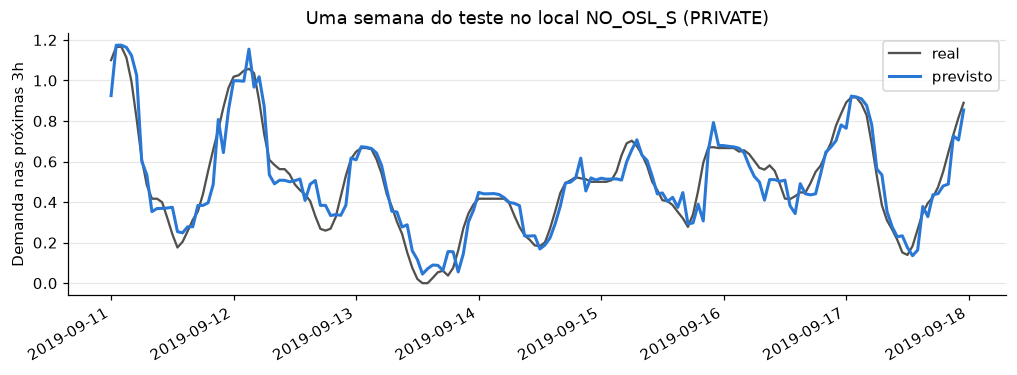

In [5]:
sample_site = test[test["site_id"] == "NO_OSL_S"].iloc[: 24 * 7]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    sample_site["timestamp"],
    sample_site["next_demand"],
    color="#52514e",
    lw=1.5,
    label="real",
)
ax.plot(
    sample_site["timestamp"],
    sample_site["model"],
    color=COLORS[PRIVATE],
    lw=2,
    label="previsto",
)
ax.set_ylabel("Demanda nas próximas 3h")
ax.set_title("Uma semana do teste no local NO_OSL_S (PRIVATE)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()

## 4. O que o modelo aprendeu

Duas medidas de importância das variáveis:

- **Importância por impureza** (`feature_importances_`): quanto cada variável reduz o erro nas divisões das árvores durante o treino.
- **Importância por permutação** no teste: quanto o erro aumenta quando embaralhamos uma variável. É mais confiável porque mede o efeito em dados que o modelo não viu.

,impureza,permutação (aumento do MAE)
occupancy_ratio,0.929,2.953e-01
hour,0.054,2.157e-02
is_commercial,0.010,9.258e-03
day_of_week,0.003,1.673e-03
queue_length,0.002,3.580e-03
is_weekend,0.002,8.272e-04


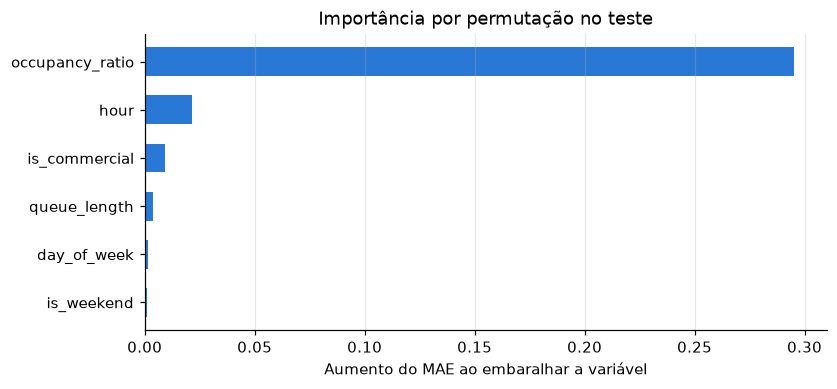

In [6]:
test_sample = test.sample(n=20_000, random_state=RANDOM_SEED)
permutation = permutation_importance(
    model.estimator,
    build_demand_features(test_sample),
    test_sample["next_demand"],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_SEED,
)
importance = pd.DataFrame(
    {
        "impureza": model.estimator.feature_importances_,
        "permutação (aumento do MAE)": permutation.importances_mean,
    },
    index=DEMAND_FEATURES,
).sort_values("permutação (aumento do MAE)")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(
    importance.index,
    importance["permutação (aumento do MAE)"],
    color=COLORS[PRIVATE],
    height=0.6,
)
ax.set_xlabel("Aumento do MAE ao embaralhar a variável")
ax.set_title("Importância por permutação no teste")
ax.grid(axis="x", alpha=0.3)
importance.sort_values("impureza", ascending=False)

**Leitura:** a **ocupação atual** é de longe a variável mais importante, como o notebook 01 antecipava. A **hora do dia** vem em segundo lugar: é ela que permite ao modelo corrigir a persistência, prevendo que a garagem vai encher no fim da tarde e esvaziar de manhã. O **tipo de ponto** separa os dois comportamentos. Dia da semana, fim de semana e fila têm peso pequeno. A fila é rara (2% das horas) e só acontece quando a ocupação já está em 100%, então ela pouco acrescenta à informação que a ocupação já traz.

### Como o fator responde a cada situação

A grade abaixo consulta o modelo para todas as horas do dia em uma quarta-feira, com três níveis de ocupação atual e sem fila. Ela mostra se o comportamento faz sentido para o negócio: **fator maior quando o estacionamento está mais cheio** e variação ao longo do dia coerente com os padrões do notebook 01.

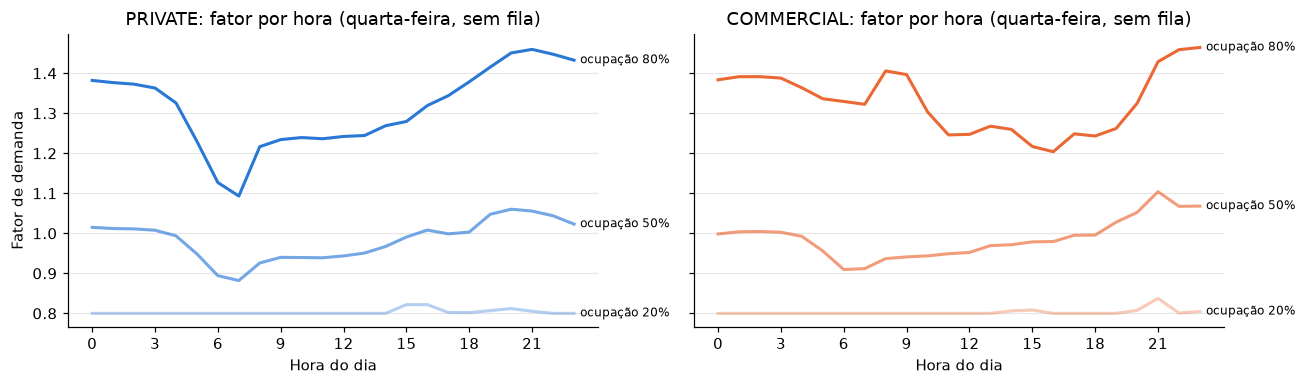

In [7]:
grid = pd.DataFrame(
    [
        {
            "hour": hour,
            "day_of_week": 2,
            "occupancy_ratio": occupancy,
            "queue_length": 0,
            "charge_point_type": charge_point_type,
        }
        for charge_point_type in TYPES
        for occupancy in (0.2, 0.5, 0.8)
        for hour in range(24)
    ]
)
grid["factor"] = model.predict_factor(grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, charge_point_type in zip(axes, TYPES):
    subset = grid[grid["charge_point_type"] == charge_point_type]
    for occupancy, alpha in zip((0.2, 0.5, 0.8), (0.35, 0.65, 1.0)):
        line = subset[subset["occupancy_ratio"] == occupancy]
        ax.plot(
            line["hour"],
            line["factor"],
            color=COLORS[charge_point_type],
            alpha=alpha,
            lw=2,
        )
        ax.annotate(
            f"ocupação {occupancy:.0%}",
            (23, line["factor"].iloc[-1]),
            xytext=(4, 0),
            textcoords="offset points",
            fontsize=8,
            va="center",
        )
    ax.set_title(f"{charge_point_type}: fator por hora (quarta-feira, sem fila)")
    ax.set_xlabel("Hora do dia")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Fator de demanda")
fig.tight_layout()

In [8]:
occupancy_grid = pd.DataFrame(
    {
        "hour": 21,
        "day_of_week": 2,
        "occupancy_ratio": np.repeat(np.linspace(0, 1, 21), 2),
        "queue_length": 0,
        "charge_point_type": TYPES * 21,
    }
)
occupancy_grid["demand"] = model.predict_demand(occupancy_grid)
monotonic = {
    charge_point_type: bool(
        np.all(np.diff(group.sort_values("occupancy_ratio")["demand"]) >= -0.01)
    )
    for charge_point_type, group in occupancy_grid.groupby("charge_point_type")
}
scenarios = pd.DataFrame(
    [
        ("madrugada, garagem quase vazia", 3, 2, 0.1, 0, PRIVATE),
        ("início da tarde, pouco uso", 14, 2, 0.3, 0, PRIVATE),
        ("moradores chegando", 18, 2, 0.6, 0, PRIVATE),
        ("noite, garagem cheia com fila", 22, 2, 1.0, 2, PRIVATE),
        ("domingo à tarde", 15, 6, 0.4, 0, PRIVATE),
        ("ponto rotativo livre de manhã", 9, 2, 0.0, 0, COMMERCIAL),
        ("ponto rotativo ocupado de manhã", 9, 2, 1.0, 0, COMMERCIAL),
    ],
    columns=[
        "cenário",
        "hour",
        "day_of_week",
        "occupancy_ratio",
        "queue_length",
        "charge_point_type",
    ],
)
scenarios["demanda prevista"] = model.predict_demand(scenarios)
scenarios["fator"] = model.predict_factor(scenarios)
print("demanda não decresce com a ocupação (tolerância 0,01):", monotonic)
scenarios.set_index("cenário")

demanda não decresce com a ocupação (tolerância 0,01): {'COMMERCIAL': True, 'PRIVATE': True}


,hour,day_of_week,occupancy_ratio,queue_length,charge_point_type,demanda prevista,fator
cenário,,,,,,,
"madrugada, garagem quase vazia",3,2,0.1,0,PRIVATE,0.101,0.800
"início da tarde, pouco uso",14,2,0.3,0,PRIVATE,0.320,0.856
moradores chegando,18,2,0.6,0,PRIVATE,0.594,1.117
"noite, garagem cheia com fila",22,2,1.0,2,PRIVATE,1.224,1.500
domingo à tarde,15,6,0.4,0,PRIVATE,0.435,0.948
ponto rotativo livre de manhã,9,2,0.0,0,COMMERCIAL,0.052,0.800
ponto rotativo ocupado de manhã,9,2,1.0,0,COMMERCIAL,0.897,1.496


**Leitura:**

- **O fator cresce com a ocupação** em todas as horas e nos dois tipos de ponto (o teste automático acima confirma que a demanda prevista não diminui quando a ocupação aumenta). Isso é essencial para a confiança do morador: o preço nunca fica mais barato porque o estacionamento ficou mais cheio. O `GradientBoostingRegressor` do scikit-learn não permite impor essa regra durante o treino, então ela é verificada aqui e nos testes automatizados do repositório.
- **A hora muda o fator para a mesma ocupação.** No uso residencial, com 80% de ocupação, o fator é maior à noite (cerca de 1,45 às 21h, quando ainda chegam moradores) do que às 7h (cerca de 1,1, quando eles estão saindo e vão liberar pontos). O modelo antecipa o movimento.
- **Cenários:** garagem quase vazia de madrugada paga 0,8; com moradores chegando às 18h e 60% de ocupação, 1,12; garagem cheia com fila à noite, 1,5.
- **Atenção para `COMMERCIAL`:** nos dados de treino cada estação pública tem um único ponto, então a ocupação observada é sempre 0 ou 1. Os valores intermediários (como 50%) que aparecem no gráfico são interpolações do modelo, sem dados reais por trás. Para condomínios com vários pontos comerciais, esse é o primeiro comportamento a recalibrar com dados próprios.

## 5. Do índice de demanda ao fator de preço

A conversão é linear por partes, com pontos de controle definidos em `ml.models.demand_factor`:

| Índice de demanda previsto | Fator | Interpretação |
|---|---|---|
| até 0,25 | 0,8 | fora de pico: menos de um quarto dos pontos ocupados |
| 0,50 | 1,0 | normal: metade da capacidade |
| 0,90 ou mais | 1,5 | pico: estacionamento praticamente cheio |

Entre os pontos o fator cresce linearmente, e o resultado é sempre limitado ao intervalo [0,8; 1,5]. Os valores são uma **decisão de negócio** (o síndico pode ajustar), não algo aprendido pelo modelo. Com essa regra, a tarifa média fica próxima da tarifa base: o desconto fora de pico compensa parte do acréscimo no pico.

,mean,25%,50%,75%,max
charge_point_type,,,,,
COMMERCIAL,0.914,0.800,0.800,0.800,1.5
PRIVATE,1.074,0.846,1.009,1.265,1.5


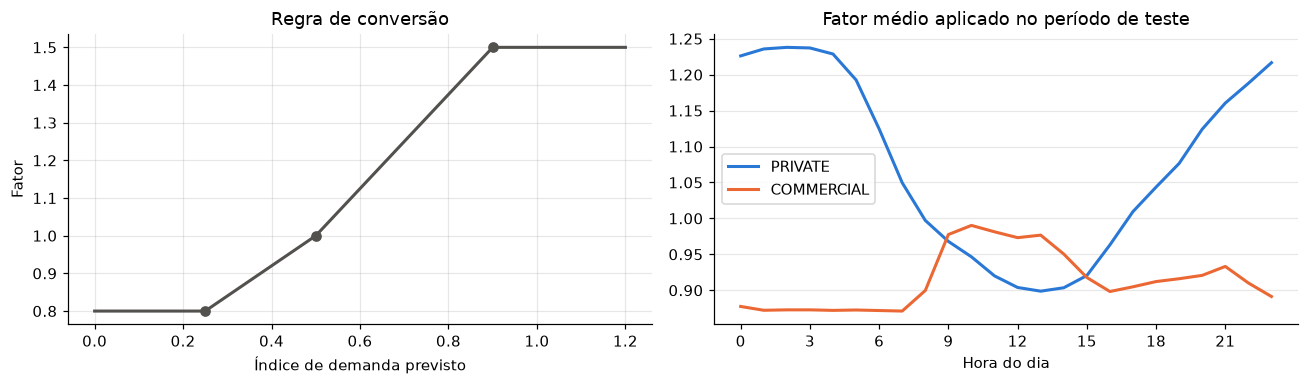

In [9]:
demand_axis = np.linspace(0, 1.2, 121)
test["factor"] = demand_to_factor(test["model"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(demand_axis, demand_to_factor(demand_axis), color="#52514e", lw=2)
axes[0].scatter(DEMAND_KNOTS, FACTOR_KNOTS, color="#52514e", zorder=3)
axes[0].set_xlabel("Índice de demanda previsto")
axes[0].set_ylabel("Fator")
axes[0].set_title("Regra de conversão")
axes[0].grid(alpha=0.3)
for charge_point_type in TYPES:
    hourly = (
        test[test["charge_point_type"] == charge_point_type]
        .groupby(test["timestamp"].dt.hour)["factor"]
        .mean()
    )
    axes[1].plot(
        hourly.index,
        hourly,
        color=COLORS[charge_point_type],
        lw=2,
        label=charge_point_type,
    )
axes[1].set_xlabel("Hora do dia")
axes[1].set_title("Fator médio aplicado no período de teste")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
test.groupby("charge_point_type")["factor"].describe()[
    ["mean", "25%", "50%", "75%", "max"]
]

**Leitura:** no período de teste, o fator médio ficou em **1,07 no uso residencial** e **0,91 no público**. No residencial ele varia de cerca de 0,9 no início da tarde até perto de 1,25 de madrugada, acompanhando a ocupação. No público a maior parte das horas fica em 0,8 (ponto livre), com fator mais alto pela manhã. Na prática:

- quem carrega no início da tarde paga em média 10% abaixo da tarifa base;
- quem conecta à noite, quando a garagem está cheia e outros moradores esperam, paga até 50% a mais.

Como o fator é aplicado sobre o kWh medido, o rateio continua proporcional ao consumo de cada morador. O fator só desloca o incentivo de horário.

## Conclusões

1. **O modelo cumpre um papel que regras simples não cumprem.** Ele supera a média histórica por larga margem e supera a persistência em R² e RMSE nos dois tipos de ponto (R² de 0,90 no residencial), principalmente nos momentos de transição, que são justamente os que importam para o preço.
2. **O comportamento é coerente com o negócio:** o fator cresce com a ocupação, antecipa a chegada dos moradores e respeita o intervalo [0,8; 1,5].
3. **Previsão e preço estão separados.** O modelo prevê um índice de demanda interpretável; a conversão para fator é uma regra explícita, documentada e ajustável pelo síndico.
4. **Integração:** o artefato `artifacts/demand_factor/v1/model.joblib` é carregado pela API (`POST /demand-factor`) com as mesmas funções de `ml.features` usadas no treino, o que evita diferenças entre treino e produção.
5. **Limitações:**
   - Os dados são da Noruega e da Finlândia, e a capacidade dos locais foi estimada (percentil 95 de uso).
   - No uso `COMMERCIAL` só há estações de um ponto, então ocupações intermediárias são extrapoladas.
   - A persistência ainda empata com o modelo no erro absoluto médio do uso público.
   - O modelo deve ser retreinado com o histórico do próprio condomínio assim que houver alguns meses de dados, usando `uv run python -m ml.training.train`.